In [3]:
# ============================================================================
# MODEL COMPARISON ANALYSIS
# ============================================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("="*70)
print("MODEL COMPARISON ANALYSIS: XGBoost vs VAE")
print("="*70)

# ============================================================================
# 1. LOAD RESULTS
# ============================================================================

with open('results/xgboost_results.pkl', 'rb') as f:
    xgboost_package = pickle.load(f)

with open('results/vae_results.pkl', 'rb') as f:
    vae_package = pickle.load(f)

xgboost_results = xgboost_package['results']
vae_results = vae_package['results']

print(f"\n✓ Loaded results:")
print(f"  XGBoost: {len(xgboost_results)} sessions")
print(f"  VAE:     {len(vae_results)} sessions")

# ============================================================================
# 2. CREATE COMPARISON DATAFRAME - WITH SESSION MATCHING
# ============================================================================

# Convert results lists to dictionaries keyed by session for easy matching
xgboost_dict = {res['session']: res for res in xgboost_results}
vae_dict = {res['session']: res for res in vae_results}

# Find common sessions
common_sessions = set(xgboost_dict.keys()) & set(vae_dict.keys())
print(f"\n✓ Found {len(common_sessions)} common sessions")

# Check for mismatches
xgb_only = set(xgboost_dict.keys()) - set(vae_dict.keys())
vae_only = set(vae_dict.keys()) - set(xgboost_dict.keys())

if xgb_only:
    print(f"⚠ XGBoost-only sessions: {xgb_only}")
if vae_only:
    print(f"⚠ VAE-only sessions: {vae_only}")

comparison_data = []

for session_id in sorted(common_sessions):  # Sort for consistency
    xgb_res = xgboost_dict[session_id]
    vae_res = vae_dict[session_id]

    # Get session metadata from df
    df = xgb_res['df']
    duration_sec = len(df)
    hr_std = df['heart_rate'].std()
    hr_mean = df['heart_rate'].mean()

    # Determine sport
    sport = xgb_res.get('sport', 'unknown')
    if sport == 'unknown':
        if 'Bike' in xgb_res['athlete']:
            sport = 'biking'
        elif 'Rowing' in xgb_res['athlete']:
            sport = 'rowing'
        else:
            sport = 'rowing' if 'Athlete12' in xgb_res['athlete'] else 'biking'

    comparison_data.append({
        'session': xgb_res['session'],
        'athlete': xgb_res['athlete'],
        'sport': sport,
        'n_intervals': xgb_res['n_true'],
        'duration_sec': duration_sec,
        'duration_min': duration_sec / 60,
        'hr_std': hr_std,
        'hr_mean': hr_mean,
        'xgboost_fbeta': xgb_res['f_beta'],
        'xgboost_precision': xgb_res['precision'],
        'xgboost_recall': xgb_res['recall'],
        'vae_fbeta': vae_res['f_beta'],
        'vae_precision': vae_res['precision'],
        'vae_recall': vae_res['recall'],
        'fbeta_diff': vae_res['f_beta'] - xgb_res['f_beta'],
        'winner': 'VAE' if vae_res['f_beta'] > xgb_res['f_beta'] else 'XGBoost' if xgb_res['f_beta'] > vae_res['f_beta'] else 'Tie',
    })

df_comparison = pd.DataFrame(comparison_data)

# Add complexity category
df_comparison['complexity'] = pd.cut(
    df_comparison['n_intervals'],
    bins=[0, 10, 20, 100],
    labels=['Low (≤10)', 'Medium (11-20)', 'High (>20)']
)

print(f"\n✓ Comparison dataframe created: {len(df_comparison)} sessions")

# ============================================================================
# 3. OVERALL STATISTICS
# ============================================================================

print("\n" + "="*70)
print("OVERALL PERFORMANCE")
print("="*70)

xgb_mean = df_comparison['xgboost_fbeta'].mean()
vae_mean = df_comparison['vae_fbeta'].mean()

print(f"\nMean F_beta:")
print(f"  XGBoost: {xgb_mean:.3f}")
print(f"  VAE:     {vae_mean:.3f}")
print(f"  Difference: {vae_mean - xgb_mean:+.3f}")

print(f"\nWin/Loss/Tie:")
win_counts = df_comparison['winner'].value_counts()
for model, count in win_counts.items():
    pct = 100 * count / len(df_comparison)
    print(f"  {model}: {count} sessions ({pct:.1f}%)")

# ============================================================================
# 4. BREAKDOWN BY SPORT
# ============================================================================

print("\n" + "="*70)
print("PERFORMANCE BY SPORT")
print("="*70)

for sport in df_comparison['sport'].unique():
    sport_df = df_comparison[df_comparison['sport'] == sport]

    xgb_sport = sport_df['xgboost_fbeta'].mean()
    vae_sport = sport_df['vae_fbeta'].mean()

    print(f"\n{sport.upper()} ({len(sport_df)} sessions):")
    print(f"  XGBoost: {xgb_sport:.3f}")
    print(f"  VAE:     {vae_sport:.3f}")
    print(f"  Difference: {vae_sport - xgb_sport:+.3f}")

    sport_wins = sport_df['winner'].value_counts()
    for model, count in sport_wins.items():
        pct = 100 * count / len(sport_df)
        print(f"  {model} wins: {count} ({pct:.1f}%)")

# ============================================================================
# 5. BREAKDOWN BY COMPLEXITY
# ============================================================================

print("\n" + "="*70)
print("PERFORMANCE BY SESSION COMPLEXITY")
print("="*70)

for complexity in ['Low (≤10)', 'Medium (11-20)', 'High (>20)']:
    comp_df = df_comparison[df_comparison['complexity'] == complexity]

    if len(comp_df) == 0:
        continue

    xgb_comp = comp_df['xgboost_fbeta'].mean()
    vae_comp = comp_df['vae_fbeta'].mean()

    print(f"\n{complexity} INTERVALS ({len(comp_df)} sessions):")
    print(f"  XGBoost: {xgb_comp:.3f}")
    print(f"  VAE:     {vae_comp:.3f}")
    print(f"  Difference: {vae_comp - xgb_comp:+.3f}")

    comp_wins = comp_df['winner'].value_counts()
    for model, count in comp_wins.items():
        pct = 100 * count / len(comp_df)
        print(f"  {model} wins: {count} ({pct:.1f}%)")

# ============================================================================
# 6. SESSION-BY-SESSION TABLE
# ============================================================================

print("\n" + "="*70)
print("SESSION-BY-SESSION COMPARISON")
print("="*70)

# Sort by absolute difference
df_sorted = df_comparison.sort_values('fbeta_diff', key=abs, ascending=False)

print(f"\n{'Session':<40} {'Sport':<8} {'Int':<4} {'XGB':<6} {'VAE':<6} {'Diff':<7} {'Winner':<10}")
print("-" * 90)

for _, row in df_sorted.iterrows():
    session_short = row['session'][:37] + "..." if len(row['session']) > 40 else row['session']
    print(f"{session_short:<40} {row['sport']:<8} {row['n_intervals']:<4} "
          f"{row['xgboost_fbeta']:<6.3f} {row['vae_fbeta']:<6.3f} "
          f"{row['fbeta_diff']:+7.3f} {row['winner']:<10}")

# ============================================================================
# 7. VISUALIZATIONS
# ============================================================================

print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

# Plot 1: Scatter plot
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(df_comparison['xgboost_fbeta'], df_comparison['vae_fbeta'],
           s=100, alpha=0.6, c='steelblue', edgecolors='black')
ax.plot([0, 1], [0, 1], 'r--', label='Equal performance', linewidth=2)
ax.set_xlabel('XGBoost F_beta', fontsize=14)
ax.set_ylabel('VAE F_beta', fontsize=14)
ax.set_title('XGBoost vs VAE Performance (Session-by-Session)', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('results/comparison_scatter.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/comparison_scatter.png")
plt.close()

# Plot 2: Bar chart by category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By sport
sport_stats = df_comparison.groupby('sport')[['xgboost_fbeta', 'vae_fbeta']].mean()
sport_stats.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Average F_beta by Sport', fontsize=14)
axes[0].set_ylabel('F_beta', fontsize=12)
axes[0].set_xlabel('Sport', fontsize=12)
axes[0].legend(['XGBoost', 'VAE'], fontsize=11)
axes[0].set_xticklabels(sport_stats.index, rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# By complexity
comp_stats = df_comparison.groupby('complexity')[['xgboost_fbeta', 'vae_fbeta']].mean()
comp_stats.plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Average F_beta by Complexity', fontsize=14)
axes[1].set_ylabel('F_beta', fontsize=12)
axes[1].set_xlabel('Number of Intervals', fontsize=12)
axes[1].legend(['XGBoost', 'VAE'], fontsize=11)
axes[1].set_xticklabels(comp_stats.index, rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/comparison_categories.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/comparison_categories.png")
plt.close()

# Plot 3: Difference heatmap
fig, ax = plt.subplots(figsize=(12, 8))
pivot = df_comparison.pivot_table(
    values='fbeta_diff',
    index='complexity',
    columns='sport',
    aggfunc='mean'
)
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'VAE - XGBoost F_beta'}, ax=ax)
ax.set_title('Performance Difference (VAE - XGBoost) by Category', fontsize=14)
plt.tight_layout()
plt.savefig('results/comparison_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/comparison_heatmap.png")
plt.close()

# ============================================================================
# 8. SAVE COMPARISON TABLE
# ============================================================================

df_comparison.to_csv('results/comparison_table.csv', index=False)
print("\n✓ Saved: results/comparison_table.csv")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)

MODEL COMPARISON ANALYSIS: XGBoost vs VAE

✓ Loaded results:
  XGBoost: 18 sessions
  VAE:     18 sessions

✓ Found 18 common sessions

✓ Comparison dataframe created: 18 sessions

OVERALL PERFORMANCE

Mean F_beta:
  XGBoost: 0.725
  VAE:     0.684
  Difference: -0.041

Win/Loss/Tie:
  XGBoost: 8 sessions (44.4%)
  Tie: 6 sessions (33.3%)
  VAE: 4 sessions (22.2%)

PERFORMANCE BY SPORT

BIKING (6 sessions):
  XGBoost: 0.573
  VAE:     0.688
  Difference: +0.115
  VAE wins: 4 (66.7%)
  Tie wins: 2 (33.3%)

ROWING (12 sessions):
  XGBoost: 0.802
  VAE:     0.682
  Difference: -0.120
  XGBoost wins: 8 (66.7%)
  Tie wins: 4 (33.3%)

PERFORMANCE BY SESSION COMPLEXITY

Low (≤10) INTERVALS (8 sessions):
  XGBoost: 0.773
  VAE:     0.662
  Difference: -0.111
  XGBoost wins: 5 (62.5%)
  Tie wins: 2 (25.0%)
  VAE wins: 1 (12.5%)

Medium (11-20) INTERVALS (6 sessions):
  XGBoost: 0.736
  VAE:     0.708
  Difference: -0.028
  Tie wins: 3 (50.0%)
  XGBoost wins: 2 (33.3%)
  VAE wins: 1 (16.7%)

Hig

C:\Users\katha\AppData\Local\Temp\ipykernel_18180\2435545718.py:241: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comp_stats = df_comparison.groupby('complexity')[['xgboost_fbeta', 'vae_fbeta']].mean()


✓ Saved: results/comparison_categories.png


C:\Users\katha\AppData\Local\Temp\ipykernel_18180\2435545718.py:257: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_comparison.pivot_table(


✓ Saved: results/comparison_heatmap.png

✓ Saved: results/comparison_table.csv

ANALYSIS COMPLETE


In [4]:
# ============================================================================
# ADDITIONAL COMPARISON METRICS
# ============================================================================

print("\n" + "="*70)
print("DETAILED METRICS COMPARISON")
print("="*70)

# 1. TIMING ACCURACY
print("\n1. TIMING ACCURACY (Mean Absolute Error in seconds)")
print("-" * 70)
print(f"{'Session':<40} {'XGB MAE':<10} {'VAE MAE':<10} {'Difference':<12}")
print("-" * 70)

for _, row in df_comparison.head(10).iterrows():
    session_short = row['session'][:37] + "..."
    xgb_mae = xgboost_dict[row['session']]['mean_error_sec']
    vae_mae = vae_dict[row['session']]['mean_error_sec']
    diff = vae_mae - xgb_mae
    print(f"{session_short:<40} {xgb_mae:<10.1f} {vae_mae:<10.1f} {diff:+12.1f}")

# 2. FALSE POSITIVE/NEGATIVE ANALYSIS
print("\n2. FALSE POSITIVE & FALSE NEGATIVE RATES")
print("-" * 70)

comparison_data_detailed = []

for session_id in sorted(common_sessions):
    xgb_res = xgboost_dict[session_id]
    vae_res = vae_dict[session_id]

    # Calculate FP and FN
    xgb_tp = xgb_res['recall'] * xgb_res['n_true']
    xgb_fp = xgb_res['n_pred'] - xgb_tp
    xgb_fn = xgb_res['n_true'] - xgb_tp

    vae_tp = vae_res['recall'] * vae_res['n_true']
    vae_fp = vae_res['n_pred'] - vae_tp
    vae_fn = vae_res['n_true'] - vae_tp

    comparison_data_detailed.append({
        'session': session_id,
        'n_true': xgb_res['n_true'],
        'xgb_fp': xgb_fp,
        'xgb_fn': xgb_fn,
        'vae_fp': vae_fp,
        'vae_fn': vae_fn,
        'xgb_fp_rate': xgb_fp / xgb_res['n_pred'] if xgb_res['n_pred'] > 0 else 0,
        'vae_fp_rate': vae_fp / vae_res['n_pred'] if vae_res['n_pred'] > 0 else 0,
        'xgb_fn_rate': xgb_fn / xgb_res['n_true'] if xgb_res['n_true'] > 0 else 0,
        'vae_fn_rate': vae_fn / vae_res['n_true'] if vae_res['n_true'] > 0 else 0,
    })

df_detailed = pd.DataFrame(comparison_data_detailed)

print(f"\nAverage False Positive Rate:")
print(f"  XGBoost: {df_detailed['xgb_fp_rate'].mean():.3f}")
print(f"  VAE:     {df_detailed['vae_fp_rate'].mean():.3f}")

print(f"\nAverage False Negative Rate:")
print(f"  XGBoost: {df_detailed['xgb_fn_rate'].mean():.3f}")
print(f"  VAE:     {df_detailed['vae_fn_rate'].mean():.3f}")

# 3. CONSISTENCY (Standard Deviation)
print("\n3. MODEL CONSISTENCY (Performance Variability)")
print("-" * 70)
print(f"  XGBoost std dev: {df_comparison['xgboost_fbeta'].std():.3f}")
print(f"  VAE std dev:     {df_comparison['vae_fbeta'].std():.3f}")
print(f"  → {'XGBoost is more consistent' if df_comparison['xgboost_fbeta'].std() < df_comparison['vae_fbeta'].std() else 'VAE is more consistent'}")

# 4. FAILURE ANALYSIS (F_beta < 0.5)
print("\n4. FAILURE RATE (F_beta < 0.5)")
print("-" * 70)
xgb_failures = (df_comparison['xgboost_fbeta'] < 0.5).sum()
vae_failures = (df_comparison['vae_fbeta'] < 0.5).sum()
print(f"  XGBoost failures: {xgb_failures}/{len(df_comparison)} ({100*xgb_failures/len(df_comparison):.1f}%)")
print(f"  VAE failures:     {vae_failures}/{len(df_comparison)} ({100*vae_failures/len(df_comparison):.1f}%)")


DETAILED METRICS COMPARISON

1. TIMING ACCURACY (Mean Absolute Error in seconds)
----------------------------------------------------------------------
Session                                  XGB MAE    VAE MAE    Difference  
----------------------------------------------------------------------
10283878603_Zwift__HIT__HIT_EB_5x3_mi... 20.0       11.4               -8.6
11783093951_4x2000_sub8...               7.2        25.0              +17.8
11846980624_Platt_...                    13.9       40.3              +26.4
11962243206_Wundmanagement...            8.3        8.5                +0.2
12036692734_Exhausted...                 5.2        11.4               +6.2
12069656901_Schwitzen_im_Sitzen...       10.6       38.9              +28.3
12846436186_Synchronflug...              2.3        2.0                -0.3
13363782092_Zwift__Aerobic_Mixup_in_N... 66.7       17.9              -48.8
13557212506_Zwift__HIT__HIT_EB_7x2_mi... 6.5        7.2                +0.7
13601462878_Zehn

In [5]:
# ============================================================================
# CONFIDENCE ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("CONFIDENCE SCORE ANALYSIS")
print("="*70)

confidence_data = []

for session_id in sorted(common_sessions):
    xgb_res = xgboost_dict[session_id]
    vae_res = vae_dict[session_id]

    # Get prediction probabilities for predicted intervals (y_pred == 1)
    xgb_proba = xgb_res['y_pred_proba']
    vae_proba = vae_res['y_pred_proba']

    xgb_pred = xgb_res['y_pred']
    vae_pred = vae_res['y_pred']

    # Confidence = average probability for predicted intervals
    xgb_confidence = xgb_proba[xgb_pred == 1].mean() if (xgb_pred == 1).any() else 0
    vae_confidence = vae_proba[vae_pred == 1].mean() if (vae_pred == 1).any() else 0

    # Also get max confidence (most confident prediction)
    xgb_max_conf = xgb_proba[xgb_pred == 1].max() if (xgb_pred == 1).any() else 0
    vae_max_conf = vae_proba[vae_pred == 1].max() if (vae_pred == 1).any() else 0

    # Min confidence (least confident prediction that was still made)
    xgb_min_conf = xgb_proba[xgb_pred == 1].min() if (xgb_pred == 1).any() else 0
    vae_min_conf = vae_proba[vae_pred == 1].min() if (vae_pred == 1).any() else 0

    confidence_data.append({
        'session': session_id,
        'sport': xgb_res.get('sport', 'unknown'),
        'n_intervals': xgb_res['n_true'],
        'xgb_fbeta': xgb_res['f_beta'],
        'vae_fbeta': vae_res['f_beta'],
        'winner': 'VAE' if vae_res['f_beta'] > xgb_res['f_beta'] else 'XGBoost' if xgb_res['f_beta'] > vae_res['f_beta'] else 'Tie',
        'xgb_mean_confidence': xgb_confidence,
        'vae_mean_confidence': vae_confidence,
        'xgb_max_confidence': xgb_max_conf,
        'vae_max_confidence': vae_max_conf,
        'xgb_min_confidence': xgb_min_conf,
        'vae_min_confidence': vae_min_conf,
        'confidence_diff': vae_confidence - xgb_confidence
    })

df_confidence = pd.DataFrame(confidence_data)

# ============================================================================
# 1. OVERALL CONFIDENCE COMPARISON
# ============================================================================

print("\n1. OVERALL CONFIDENCE LEVELS")
print("-" * 70)
print(f"Average confidence in predictions:")
print(f"  XGBoost: {df_confidence['xgb_mean_confidence'].mean():.3f}")
print(f"  VAE:     {df_confidence['vae_mean_confidence'].mean():.3f}")
print(f"  Difference: {df_confidence['vae_mean_confidence'].mean() - df_confidence['xgb_mean_confidence'].mean():+.3f}")

print(f"\nMaximum confidence (most certain predictions):")
print(f"  XGBoost: {df_confidence['xgb_max_confidence'].mean():.3f}")
print(f"  VAE:     {df_confidence['vae_max_confidence'].mean():.3f}")

print(f"\nMinimum confidence (least certain predictions still made):")
print(f"  XGBoost: {df_confidence['xgb_min_confidence'].mean():.3f}")
print(f"  VAE:     {df_confidence['vae_min_confidence'].mean():.3f}")

# ============================================================================
# 2. CONFIDENCE vs PERFORMANCE CORRELATION
# ============================================================================

print("\n2. CONFIDENCE vs PERFORMANCE CORRELATION")
print("-" * 70)

from scipy.stats import pearsonr

# Does high confidence correlate with high F_beta?
xgb_corr, xgb_pval = pearsonr(df_confidence['xgb_mean_confidence'],
                                df_confidence['xgb_fbeta'])
vae_corr, vae_pval = pearsonr(df_confidence['vae_mean_confidence'],
                                df_confidence['vae_fbeta'])

print(f"Correlation between confidence and F_beta:")
print(f"  XGBoost: r={xgb_corr:.3f} (p={xgb_pval:.3f}) {'✓ Significant' if xgb_pval < 0.05 else '✗ Not significant'}")
print(f"  VAE:     r={vae_corr:.3f} (p={vae_pval:.3f}) {'✓ Significant' if vae_pval < 0.05 else '✗ Not significant'}")

print(f"\nInterpretation:")
if abs(xgb_corr) > abs(vae_corr):
    print(f"  → XGBoost's confidence is MORE predictive of its performance")
    print(f"    (When XGBoost is confident, it's more likely to be correct)")
else:
    print(f"  → VAE's confidence is MORE predictive of its performance")
    print(f"    (When VAE is confident, it's more likely to be correct)")

# ============================================================================
# 3. CONFIDENCE BY WINNER
# ============================================================================

print("\n3. CONFIDENCE WHEN EACH MODEL WINS")
print("-" * 70)

xgb_wins = df_confidence[df_confidence['winner'] == 'XGBoost']
vae_wins = df_confidence[df_confidence['winner'] == 'VAE']
ties = df_confidence[df_confidence['winner'] == 'Tie']

print(f"When XGBoost wins ({len(xgb_wins)} sessions):")
print(f"  XGBoost confidence: {xgb_wins['xgb_mean_confidence'].mean():.3f}")
print(f"  VAE confidence:     {xgb_wins['vae_mean_confidence'].mean():.3f}")
print(f"  → XGBoost is {xgb_wins['xgb_mean_confidence'].mean() - xgb_wins['vae_mean_confidence'].mean():+.3f} more confident")

print(f"\nWhen VAE wins ({len(vae_wins)} sessions):")
print(f"  XGBoost confidence: {vae_wins['xgb_mean_confidence'].mean():.3f}")
print(f"  VAE confidence:     {vae_wins['vae_mean_confidence'].mean():.3f}")
print(f"  → VAE is {vae_wins['vae_mean_confidence'].mean() - vae_wins['xgb_mean_confidence'].mean():+.3f} more confident")

print(f"\nWhen Tie ({len(ties)} sessions):")
print(f"  XGBoost confidence: {ties['xgb_mean_confidence'].mean():.3f}")
print(f"  VAE confidence:     {ties['vae_mean_confidence'].mean():.3f}")

# ============================================================================
# 4. CONFIDENCE BY SPORT
# ============================================================================

print("\n4. CONFIDENCE BY SPORT")
print("-" * 70)

for sport in sorted(df_confidence['sport'].unique()):
    sport_data = df_confidence[df_confidence['sport'] == sport]
    print(f"\n{sport.upper()} ({len(sport_data)} sessions):")
    print(f"  XGBoost confidence: {sport_data['xgb_mean_confidence'].mean():.3f}")
    print(f"  VAE confidence:     {sport_data['vae_mean_confidence'].mean():.3f}")

# ============================================================================
# 5. HIGH CONFIDENCE SESSIONS
# ============================================================================

print("\n5. SESSIONS WITH HIGHEST CONFIDENCE DIFFERENCES")
print("-" * 70)

print("\nTOP 5: XGBoost much more confident than VAE")
top_xgb_conf = df_confidence.nsmallest(5, 'confidence_diff')
print(f"{'Session':<40} {'Winner':<10} {'XGB Conf':<10} {'VAE Conf':<10} {'Diff':<10}")
print("-" * 80)
for _, row in top_xgb_conf.iterrows():
    session_short = row['session'][:37] + "..."
    print(f"{session_short:<40} {row['winner']:<10} {row['xgb_mean_confidence']:<10.3f} "
          f"{row['vae_mean_confidence']:<10.3f} {row['confidence_diff']:+10.3f}")

print("\nTOP 5: VAE much more confident than XGBoost")
top_vae_conf = df_confidence.nlargest(5, 'confidence_diff')
print(f"{'Session':<40} {'Winner':<10} {'XGB Conf':<10} {'VAE Conf':<10} {'Diff':<10}")
print("-" * 80)
for _, row in top_vae_conf.iterrows():
    session_short = row['session'][:37] + "..."
    print(f"{session_short:<40} {row['winner']:<10} {row['xgb_mean_confidence']:<10.3f} "
          f"{row['vae_mean_confidence']:<10.3f} {row['confidence_diff']:+10.3f}")

# ============================================================================
# 6. CALIBRATION: CONFIDENCE vs ACTUAL PERFORMANCE
# ============================================================================

print("\n6. MODEL CALIBRATION (Are confident predictions actually better?)")
print("-" * 70)

# Split into high/low confidence groups
xgb_high_conf = df_confidence[df_confidence['xgb_mean_confidence'] > df_confidence['xgb_mean_confidence'].median()]
xgb_low_conf = df_confidence[df_confidence['xgb_mean_confidence'] <= df_confidence['xgb_mean_confidence'].median()]

vae_high_conf = df_confidence[df_confidence['vae_mean_confidence'] > df_confidence['vae_mean_confidence'].median()]
vae_low_conf = df_confidence[df_confidence['vae_mean_confidence'] <= df_confidence['vae_mean_confidence'].median()]

print(f"XGBoost:")
print(f"  High confidence sessions: F_beta = {xgb_high_conf['xgb_fbeta'].mean():.3f}")
print(f"  Low confidence sessions:  F_beta = {xgb_low_conf['xgb_fbeta'].mean():.3f}")
print(f"  Difference: {xgb_high_conf['xgb_fbeta'].mean() - xgb_low_conf['xgb_fbeta'].mean():+.3f}")

print(f"\nVAE:")
print(f"  High confidence sessions: F_beta = {vae_high_conf['vae_fbeta'].mean():.3f}")
print(f"  Low confidence sessions:  F_beta = {vae_low_conf['vae_fbeta'].mean():.3f}")
print(f"  Difference: {vae_high_conf['vae_fbeta'].mean() - vae_low_conf['vae_fbeta'].mean():+.3f}")

# ============================================================================
# 7. VISUALIZATION: Confidence vs Performance
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost
axes[0].scatter(df_confidence['xgb_mean_confidence'], df_confidence['xgb_fbeta'],
                s=100, alpha=0.6, c='steelblue', edgecolors='black')
axes[0].set_xlabel('Mean Prediction Confidence', fontsize=12)
axes[0].set_ylabel('F_beta Score', fontsize=12)
axes[0].set_title(f'XGBoost: Confidence vs Performance\n(r={xgb_corr:.3f})', fontsize=14)
axes[0].grid(True, alpha=0.3)

# VAE
axes[1].scatter(df_confidence['vae_mean_confidence'], df_confidence['vae_fbeta'],
                s=100, alpha=0.6, c='orange', edgecolors='black')
axes[1].set_xlabel('Mean Prediction Confidence', fontsize=12)
axes[1].set_ylabel('F_beta Score', fontsize=12)
axes[1].set_title(f'VAE: Confidence vs Performance\n(r={vae_corr:.3f})', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/confidence_vs_performance.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/confidence_vs_performance.png")
plt.close()

# Save confidence data
df_confidence.to_csv('results/confidence_analysis.csv', index=False)
print("✓ Saved: results/confidence_analysis.csv")


CONFIDENCE SCORE ANALYSIS

1. OVERALL CONFIDENCE LEVELS
----------------------------------------------------------------------
Average confidence in predictions:
  XGBoost: 0.454
  VAE:     0.075
  Difference: -0.378

Maximum confidence (most certain predictions):
  XGBoost: 0.748
  VAE:     0.306

Minimum confidence (least certain predictions still made):
  XGBoost: 0.229
  VAE:     0.021

2. CONFIDENCE vs PERFORMANCE CORRELATION
----------------------------------------------------------------------
Correlation between confidence and F_beta:
  XGBoost: r=0.443 (p=0.065) ✗ Not significant
  VAE:     r=0.573 (p=0.013) ✓ Significant

Interpretation:
  → VAE's confidence is MORE predictive of its performance
    (When VAE is confident, it's more likely to be correct)

3. CONFIDENCE WHEN EACH MODEL WINS
----------------------------------------------------------------------
When XGBoost wins (8 sessions):
  XGBoost confidence: 0.417
  VAE confidence:     0.072
  → XGBoost is +0.344 more co

In [6]:
# Check VAE probability distribution
print("\n" + "="*70)
print("VAE PROBABILITY DISTRIBUTION ANALYSIS")
print("="*70)

for session_id in sorted(common_sessions)[:3]:  # Check first 3 sessions
    vae_res = vae_dict[session_id]
    vae_proba = vae_res['y_pred_proba']

    print(f"\nSession: {session_id[:40]}")
    print(f"  Mean probability: {vae_proba.mean():.4f}")
    print(f"  Median probability: {np.median(vae_proba):.4f}")
    print(f"  Max probability: {vae_proba.max():.4f}")
    print(f"  95th percentile: {np.percentile(vae_proba, 95):.4f}")
    print(f"  Predicted intervals: {vae_res['n_pred']}")
    print(f"  True intervals: {vae_res['n_true']}")

    # What threshold was used?
    threshold = vae_proba[vae_res['y_pred'] == 1].min() if (vae_res['y_pred'] == 1).any() else 0
    print(f"  Implied threshold: {threshold:.4f}")


VAE PROBABILITY DISTRIBUTION ANALYSIS

Session: 10283878603_Zwift__HIT__HIT_EB_5x3_min_i
  Mean probability: 0.0024
  Median probability: 0.0001
  Max probability: 0.3967
  95th percentile: 0.0088
  Predicted intervals: 8
  True intervals: 8
  Implied threshold: 0.0021

Session: 11783093951_4x2000_sub8
  Mean probability: 0.0026
  Median probability: 0.0000
  Max probability: 0.3207
  95th percentile: 0.0091
  Predicted intervals: 9
  True intervals: 9
  Implied threshold: 0.0362

Session: 11846980624_Platt_
  Mean probability: 0.0084
  Median probability: 0.0012
  Max probability: 0.4216
  95th percentile: 0.0390
  Predicted intervals: 10
  True intervals: 10
  Implied threshold: 0.0096


In [7]:
# ============================================================================
# VAE PROBABILITY CALIBRATION
# ============================================================================

print("\n" + "="*70)
print("CALIBRATING VAE PROBABILITIES")
print("="*70)

from sklearn.calibration import calibration_curve
from scipy.special import expit  # sigmoid function

# Collect all VAE probabilities and true labels
all_vae_proba = []
all_vae_true = []

for session_id in common_sessions:
    vae_res = vae_dict[session_id]
    all_vae_proba.extend(vae_res['y_pred_proba'])
    all_vae_true.extend(vae_res['y_true'])

all_vae_proba = np.array(all_vae_proba)
all_vae_true = np.array(all_vae_true)

print(f"\nOriginal VAE probability statistics:")
print(f"  Mean: {all_vae_proba.mean():.4f}")
print(f"  Median: {np.median(all_vae_proba):.4f}")
print(f"  95th percentile: {np.percentile(all_vae_proba, 95):.4f}")
print(f"  Max: {all_vae_proba.max():.4f}")

# METHOD 1: Platt Scaling (fit logistic regression)
# This learns: calibrated_prob = 1 / (1 + exp(-(a * raw_prob + b)))

from sklearn.linear_model import LogisticRegression

# Reshape for sklearn
X = all_vae_proba.reshape(-1, 1)
y = all_vae_true

# Fit Platt scaling
platt_scaler = LogisticRegression()
platt_scaler.fit(X, y)

# Apply calibration
calibrated_proba = platt_scaler.predict_proba(X)[:, 1]

print(f"\nCalibrated VAE probability statistics:")
print(f"  Mean: {calibrated_proba.mean():.4f}")
print(f"  Median: {np.median(calibrated_proba):.4f}")
print(f"  95th percentile: {np.percentile(calibrated_proba, 95):.4f}")
print(f"  Max: {calibrated_proba.max():.4f}")

# METHOD 2: Simple percentile scaling (alternative)
# Map VAE probabilities to 0-1 based on their distribution

def percentile_calibration(proba):
    """Map probabilities to their percentile in distribution"""
    percentiles = np.searchsorted(np.sort(all_vae_proba), proba) / len(all_vae_proba)
    return percentiles

percentile_calibrated = percentile_calibration(all_vae_proba)

print(f"\nPercentile-calibrated VAE statistics:")
print(f"  Mean: {percentile_calibrated.mean():.4f}")
print(f"  Median: {np.median(percentile_calibrated):.4f}")
print(f"  95th percentile: {np.percentile(percentile_calibrated, 95):.4f}")

# ============================================================================
# VISUALIZATION: Before vs After Calibration
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Original VAE probability distribution
axes[0, 0].hist(all_vae_proba, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[0, 0].set_xlabel('Raw VAE Probability', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Original VAE Probabilities (Highly Skewed)', fontsize=14)
axes[0, 0].axvline(0.5, color='red', linestyle='--', label='Typical threshold')
axes[0, 0].legend()

# Plot 2: Calibrated probability distribution
axes[0, 1].hist(calibrated_proba, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_xlabel('Calibrated VAE Probability', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Calibrated VAE Probabilities (Better Spread)', fontsize=14)
axes[0, 1].axvline(0.5, color='red', linestyle='--', label='Typical threshold')
axes[0, 1].legend()

# Plot 3: Calibration curve (reliability diagram)
fraction_of_positives, mean_predicted_value = calibration_curve(
    all_vae_true, all_vae_proba, n_bins=10, strategy='quantile'
)

axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1, 0].plot(mean_predicted_value, fraction_of_positives, 's-',
                label='VAE (uncalibrated)', color='orange', markersize=8)
axes[1, 0].set_xlabel('Mean Predicted Probability', fontsize=12)
axes[1, 0].set_ylabel('Fraction of Positives', fontsize=12)
axes[1, 0].set_title('Calibration Curve: VAE Original', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Calibration curve after Platt scaling
fraction_of_positives_cal, mean_predicted_value_cal = calibration_curve(
    all_vae_true, calibrated_proba, n_bins=10, strategy='quantile'
)

axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1, 1].plot(mean_predicted_value_cal, fraction_of_positives_cal, 's-',
                label='VAE (calibrated)', color='green', markersize=8)
axes[1, 1].set_xlabel('Mean Predicted Probability', fontsize=12)
axes[1, 1].set_ylabel('Fraction of Positives', fontsize=12)
axes[1, 1].set_title('Calibration Curve: VAE Calibrated', fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/vae_calibration.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/vae_calibration.png")
plt.close()

# ============================================================================
# RE-ANALYZE CONFIDENCE WITH CALIBRATED PROBABILITIES
# ============================================================================

print("\n" + "="*70)
print("RE-ANALYSIS WITH CALIBRATED VAE CONFIDENCE")
print("="*70)

# Save calibration model for future use
import pickle
with open('results/vae_calibration_model.pkl', 'wb') as f:
    pickle.dump(platt_scaler, f)
print("✓ Saved calibration model: results/vae_calibration_model.pkl")

# Recalculate confidence scores with calibrated probabilities
confidence_data_calibrated = []

start_idx = 0
for session_id in sorted(common_sessions):
    xgb_res = xgboost_dict[session_id]
    vae_res = vae_dict[session_id]

    # Get calibrated probabilities for this session
    session_length = len(vae_res['y_pred_proba'])
    session_vae_proba_raw = all_vae_proba[start_idx:start_idx + session_length]
    session_vae_proba_cal = calibrated_proba[start_idx:start_idx + session_length]
    start_idx += session_length

    vae_pred = vae_res['y_pred']

    # Calibrated confidence
    vae_confidence_cal = session_vae_proba_cal[vae_pred == 1].mean() if (vae_pred == 1).any() else 0

    confidence_data_calibrated.append({
        'session': session_id,
        'vae_fbeta': vae_res['f_beta'],
        'vae_confidence_raw': vae_res['y_pred_proba'][vae_pred == 1].mean() if (vae_pred == 1).any() else 0,
        'vae_confidence_calibrated': vae_confidence_cal,
    })

df_cal = pd.DataFrame(confidence_data_calibrated)

print(f"\nCalibrated VAE confidence comparison:")
print(f"  Raw average:        {df_cal['vae_confidence_raw'].mean():.3f}")
print(f"  Calibrated average: {df_cal['vae_confidence_calibrated'].mean():.3f}")
print(f"\nNow comparable to XGBoost confidence of: 0.454")


CALIBRATING VAE PROBABILITIES

Original VAE probability statistics:
  Mean: 0.0046
  Median: 0.0001
  95th percentile: 0.0304
  Max: 0.5053

Calibrated VAE probability statistics:
  Mean: 0.0052
  Median: 0.0049
  95th percentile: 0.0066
  Max: 0.4780

Percentile-calibrated VAE statistics:
  Mean: 0.5000
  Median: 0.5000
  95th percentile: 0.9500

✓ Saved: results/vae_calibration.png

RE-ANALYSIS WITH CALIBRATED VAE CONFIDENCE
✓ Saved calibration model: results/vae_calibration_model.pkl

Calibrated VAE confidence comparison:
  Raw average:        0.075
  Calibrated average: 0.006

Now comparable to XGBoost confidence of: 0.454


In [8]:
# ============================================================================
# COMPREHENSIVE COMPARISON: XGBoost vs Calibrated VAE Confidence
# ============================================================================

print("\n" + "="*70)
print("CONFIDENCE COMPARISON: XGBoost vs Calibrated VAE")
print("="*70)

# Recalculate all confidence metrics with calibrated VAE
confidence_comparison = []

start_idx = 0
for session_id in sorted(common_sessions):
    xgb_res = xgboost_dict[session_id]
    vae_res = vae_dict[session_id]

    # XGBoost confidence (unchanged)
    xgb_proba = xgb_res['y_pred_proba']
    xgb_pred = xgb_res['y_pred']
    xgb_confidence = xgb_proba[xgb_pred == 1].mean() if (xgb_pred == 1).any() else 0
    xgb_max_conf = xgb_proba[xgb_pred == 1].max() if (xgb_pred == 1).any() else 0
    xgb_min_conf = xgb_proba[xgb_pred == 1].min() if (xgb_pred == 1).any() else 0

    # VAE calibrated confidence
    session_length = len(vae_res['y_pred_proba'])
    session_vae_proba_cal = calibrated_proba[start_idx:start_idx + session_length]
    start_idx += session_length

    vae_pred = vae_res['y_pred']
    vae_confidence_raw = vae_res['y_pred_proba'][vae_pred == 1].mean() if (vae_pred == 1).any() else 0
    vae_confidence_cal = session_vae_proba_cal[vae_pred == 1].mean() if (vae_pred == 1).any() else 0
    vae_max_conf_cal = session_vae_proba_cal[vae_pred == 1].max() if (vae_pred == 1).any() else 0
    vae_min_conf_cal = session_vae_proba_cal[vae_pred == 1].min() if (vae_pred == 1).any() else 0

    confidence_comparison.append({
        'session': session_id,
        'sport': xgb_res.get('sport', 'unknown'),
        'n_intervals': xgb_res['n_true'],
        'complexity': 'Low (≤10)' if xgb_res['n_true'] <= 10 else 'Medium (11-20)' if xgb_res['n_true'] <= 20 else 'High (>20)',
        # Performance
        'xgb_fbeta': xgb_res['f_beta'],
        'vae_fbeta': vae_res['f_beta'],
        'winner': 'VAE' if vae_res['f_beta'] > xgb_res['f_beta'] else 'XGBoost' if xgb_res['f_beta'] > vae_res['f_beta'] else 'Tie',
        # Raw confidence
        'xgb_confidence': xgb_confidence,
        'vae_confidence_raw': vae_confidence_raw,
        # Calibrated confidence
        'vae_confidence_cal': vae_confidence_cal,
        'confidence_diff_cal': vae_confidence_cal - xgb_confidence,
        # Min/Max
        'xgb_max_conf': xgb_max_conf,
        'vae_max_conf_cal': vae_max_conf_cal,
        'xgb_min_conf': xgb_min_conf,
        'vae_min_conf_cal': vae_min_conf_cal,
    })

df_conf_comp = pd.DataFrame(confidence_comparison)

# ============================================================================
# 1. OVERALL CONFIDENCE COMPARISON
# ============================================================================

print("\n1. OVERALL CONFIDENCE COMPARISON (Now on Same Scale!)")
print("-" * 70)
print(f"Average confidence in predictions:")
print(f"  XGBoost:          {df_conf_comp['xgb_confidence'].mean():.3f}")
print(f"  VAE (raw):        {df_conf_comp['vae_confidence_raw'].mean():.3f}")
print(f"  VAE (calibrated): {df_conf_comp['vae_confidence_cal'].mean():.3f}")
print(f"\n  Difference (XGB - VAE_cal): {df_conf_comp['xgb_confidence'].mean() - df_conf_comp['vae_confidence_cal'].mean():+.3f}")

if df_conf_comp['xgb_confidence'].mean() > df_conf_comp['vae_confidence_cal'].mean():
    print(f"  → XGBoost is MORE confident on average")
else:
    print(f"  → VAE is MORE confident on average")

# ============================================================================
# 2. CORRELATION WITH PERFORMANCE (Now Fair Comparison!)
# ============================================================================

print("\n2. CONFIDENCE vs PERFORMANCE CORRELATION (Fair Comparison)")
print("-" * 70)

xgb_corr, xgb_pval = pearsonr(df_conf_comp['xgb_confidence'],
                                df_conf_comp['xgb_fbeta'])
vae_corr_cal, vae_pval_cal = pearsonr(df_conf_comp['vae_confidence_cal'],
                                        df_conf_comp['vae_fbeta'])

print(f"Correlation between confidence and F_beta:")
print(f"  XGBoost:          r={xgb_corr:.3f} (p={xgb_pval:.3f}) {'✓ Significant' if xgb_pval < 0.05 else '✗ Not significant'}")
print(f"  VAE (calibrated): r={vae_corr_cal:.3f} (p={vae_pval_cal:.3f}) {'✓ Significant' if vae_pval_cal < 0.05 else '✗ Not significant'}")

if abs(vae_corr_cal) > abs(xgb_corr):
    print(f"\n  → VAE's calibrated confidence is MORE predictive of performance")
    print(f"    Difference: {abs(vae_corr_cal) - abs(xgb_corr):.3f}")
else:
    print(f"\n  → XGBoost's confidence is MORE predictive of performance")
    print(f"    Difference: {abs(xgb_corr) - abs(vae_corr_cal):.3f}")

# ============================================================================
# 3. CONFIDENCE WHEN EACH MODEL WINS (Fair Comparison)
# ============================================================================

print("\n3. CONFIDENCE WHEN EACH MODEL WINS (Fair Comparison)")
print("-" * 70)

xgb_wins = df_conf_comp[df_conf_comp['winner'] == 'XGBoost']
vae_wins = df_conf_comp[df_conf_comp['winner'] == 'VAE']
ties = df_conf_comp[df_conf_comp['winner'] == 'Tie']

print(f"When XGBoost wins ({len(xgb_wins)} sessions):")
print(f"  XGBoost confidence: {xgb_wins['xgb_confidence'].mean():.3f}")
print(f"  VAE confidence:     {xgb_wins['vae_confidence_cal'].mean():.3f}")
diff = xgb_wins['xgb_confidence'].mean() - xgb_wins['vae_confidence_cal'].mean()
print(f"  → XGBoost is {abs(diff):.3f} {'more' if diff > 0 else 'less'} confident")

print(f"\nWhen VAE wins ({len(vae_wins)} sessions):")
print(f"  XGBoost confidence: {vae_wins['xgb_confidence'].mean():.3f}")
print(f"  VAE confidence:     {vae_wins['vae_confidence_cal'].mean():.3f}")
diff = vae_wins['vae_confidence_cal'].mean() - vae_wins['xgb_confidence'].mean()
print(f"  → VAE is {abs(diff):.3f} {'more' if diff > 0 else 'less'} confident")

print(f"\nWhen Tie ({len(ties)} sessions):")
print(f"  XGBoost confidence: {ties['xgb_confidence'].mean():.3f}")
print(f"  VAE confidence:     {ties['vae_confidence_cal'].mean():.3f}")

# KEY INSIGHT
print(f"\n🎯 KEY INSIGHT:")
if vae_wins['vae_confidence_cal'].mean() > vae_wins['xgb_confidence'].mean():
    print(f"   When VAE wins, it IS more confident than XGBoost!")
    print(f"   → VAE's confidence can be trusted as a selection signal")
else:
    print(f"   When VAE wins, it is NOT more confident than XGBoost")
    print(f"   → VAE might be winning on patterns XGBoost misses, not confidence")

# ============================================================================
# 4. CONFIDENCE BY SPORT (Fair Comparison)
# ============================================================================

print("\n4. CONFIDENCE BY SPORT (Fair Comparison)")
print("-" * 70)

for sport in sorted(df_conf_comp['sport'].unique()):
    if sport == 'unknown':
        continue
    sport_data = df_conf_comp[df_conf_comp['sport'] == sport]
    print(f"\n{sport.upper()} ({len(sport_data)} sessions):")
    print(f"  XGBoost confidence: {sport_data['xgb_confidence'].mean():.3f}")
    print(f"  VAE confidence:     {sport_data['vae_confidence_cal'].mean():.3f}")

    # Who performs better?
    xgb_perf = sport_data['xgb_fbeta'].mean()
    vae_perf = sport_data['vae_fbeta'].mean()
    better_model = "XGBoost" if xgb_perf > vae_perf else "VAE"

    # Who is more confident?
    xgb_conf = sport_data['xgb_confidence'].mean()
    vae_conf = sport_data['vae_confidence_cal'].mean()
    more_confident = "XGBoost" if xgb_conf > vae_conf else "VAE"

    print(f"  Better performer: {better_model} (F_beta: {max(xgb_perf, vae_perf):.3f})")
    print(f"  More confident:   {more_confident}")

    if better_model == more_confident:
        print(f"  ✓ Confidence aligns with performance!")
    else:
        print(f"  ⚠ Confidence DOES NOT align with performance")

# ============================================================================
# 5. CONFIDENCE BY COMPLEXITY (Fair Comparison)
# ============================================================================

print("\n5. CONFIDENCE BY COMPLEXITY (Fair Comparison)")
print("-" * 70)

for complexity in ['Low (≤10)', 'Medium (11-20)', 'High (>20)']:
    comp_data = df_conf_comp[df_conf_comp['complexity'] == complexity]
    if len(comp_data) == 0:
        continue

    print(f"\n{complexity} ({len(comp_data)} sessions):")
    print(f"  XGBoost confidence: {comp_data['xgb_confidence'].mean():.3f}")
    print(f"  VAE confidence:     {comp_data['vae_confidence_cal'].mean():.3f}")

    # Who performs better?
    xgb_perf = comp_data['xgb_fbeta'].mean()
    vae_perf = comp_data['vae_fbeta'].mean()
    better_model = "XGBoost" if xgb_perf > vae_perf else "VAE"

    print(f"  Better performer: {better_model} (F_beta: {max(xgb_perf, vae_perf):.3f})")

# ============================================================================
# 6. AGREEMENT ANALYSIS (Most Important!)
# ============================================================================

print("\n6. AGREEMENT ANALYSIS: When Should We Trust Each Model?")
print("-" * 70)

# High confidence from both
both_high = df_conf_comp[
    (df_conf_comp['xgb_confidence'] > 0.5) &
    (df_conf_comp['vae_confidence_cal'] > 0.5)
]
print(f"\nBoth models HIGH confidence (>0.5): {len(both_high)} sessions")
if len(both_high) > 0:
    print(f"  Average XGBoost F_beta: {both_high['xgb_fbeta'].mean():.3f}")
    print(f"  Average VAE F_beta:     {both_high['vae_fbeta'].mean():.3f}")
    print(f"  → These are 'gold standard' - auto-accept!")

# XGBoost high, VAE low
xgb_high_vae_low = df_conf_comp[
    (df_conf_comp['xgb_confidence'] > 0.5) &
    (df_conf_comp['vae_confidence_cal'] <= 0.5)
]
print(f"\nXGBoost HIGH, VAE LOW confidence: {len(xgb_high_vae_low)} sessions")
if len(xgb_high_vae_low) > 0:
    print(f"  Average XGBoost F_beta: {xgb_high_vae_low['xgb_fbeta'].mean():.3f}")
    print(f"  Average VAE F_beta:     {xgb_high_vae_low['vae_fbeta'].mean():.3f}")
    print(f"  → Use XGBoost")

# VAE high, XGBoost low
vae_high_xgb_low = df_conf_comp[
    (df_conf_comp['vae_confidence_cal'] > 0.5) &
    (df_conf_comp['xgb_confidence'] <= 0.5)
]
print(f"\nVAE HIGH, XGBoost LOW confidence: {len(vae_high_xgb_low)} sessions")
if len(vae_high_xgb_low) > 0:
    print(f"  Average XGBoost F_beta: {vae_high_xgb_low['xgb_fbeta'].mean():.3f}")
    print(f"  Average VAE F_beta:     {vae_high_xgb_low['vae_fbeta'].mean():.3f}")
    print(f"  → Consider VAE")

# Both low
both_low = df_conf_comp[
    (df_conf_comp['xgb_confidence'] <= 0.5) &
    (df_conf_comp['vae_confidence_cal'] <= 0.5)
]
print(f"\nBoth models LOW confidence (≤0.5): {len(both_low)} sessions")
if len(both_low) > 0:
    print(f"  Average XGBoost F_beta: {both_low['xgb_fbeta'].mean():.3f}")
    print(f"  Average VAE F_beta:     {both_low['vae_fbeta'].mean():.3f}")
    print(f"  → MANDATORY user review!")

# ============================================================================
# 7. VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Calibrated confidence comparison
axes[0, 0].scatter(df_conf_comp['xgb_confidence'], df_conf_comp['vae_confidence_cal'],
                   s=100, alpha=0.6, c='purple', edgecolors='black')
axes[0, 0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Equal confidence')
axes[0, 0].set_xlabel('XGBoost Confidence', fontsize=12)
axes[0, 0].set_ylabel('VAE Calibrated Confidence', fontsize=12)
axes[0, 0].set_title('Confidence Comparison (Fair Scale)', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Confidence vs Performance (XGBoost)
axes[0, 1].scatter(df_conf_comp['xgb_confidence'], df_conf_comp['xgb_fbeta'],
                   s=100, alpha=0.6, c='steelblue', edgecolors='black')
axes[0, 1].set_xlabel('XGBoost Confidence', fontsize=12)
axes[0, 1].set_ylabel('XGBoost F_beta', fontsize=12)
axes[0, 1].set_title(f'XGBoost: Confidence vs Performance (r={xgb_corr:.3f})', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Confidence vs Performance (VAE calibrated)
axes[1, 0].scatter(df_conf_comp['vae_confidence_cal'], df_conf_comp['vae_fbeta'],
                   s=100, alpha=0.6, c='orange', edgecolors='black')
axes[1, 0].set_xlabel('VAE Calibrated Confidence', fontsize=12)
axes[1, 0].set_ylabel('VAE F_beta', fontsize=12)
axes[1, 0].set_title(f'VAE: Calibrated Confidence vs Performance (r={vae_corr_cal:.3f})', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Confidence difference by winner
winner_colors = {'XGBoost': 'steelblue', 'VAE': 'orange', 'Tie': 'gray'}
colors = [winner_colors[w] for w in df_conf_comp['winner']]

axes[1, 1].scatter(df_conf_comp['confidence_diff_cal'], df_conf_comp['vae_fbeta'] - df_conf_comp['xgb_fbeta'],
                   s=100, alpha=0.6, c=colors, edgecolors='black')
axes[1, 1].axhline(0, color='black', linestyle='-', linewidth=1)
axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Confidence Difference (VAE - XGBoost)', fontsize=12)
axes[1, 1].set_ylabel('Performance Difference (VAE - XGBoost)', fontsize=12)
axes[1, 1].set_title('Does Higher Confidence → Better Performance?', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='XGBoost wins'),
                   Patch(facecolor='orange', label='VAE wins'),
                   Patch(facecolor='gray', label='Tie')]
axes[1, 1].legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('results/confidence_comparison_calibrated.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/confidence_comparison_calibrated.png")
plt.close()

# Save the comparison data
df_conf_comp.to_csv('results/confidence_comparison_calibrated.csv', index=False)
print("✓ Saved: results/confidence_comparison_calibrated.csv")

print("\n" + "="*70)
print("CALIBRATED CONFIDENCE ANALYSIS COMPLETE")
print("="*70)


CONFIDENCE COMPARISON: XGBoost vs Calibrated VAE

1. OVERALL CONFIDENCE COMPARISON (Now on Same Scale!)
----------------------------------------------------------------------
Average confidence in predictions:
  XGBoost:          0.454
  VAE (raw):        0.075
  VAE (calibrated): 0.006

  Difference (XGB - VAE_cal): +0.448
  → XGBoost is MORE confident on average

2. CONFIDENCE vs PERFORMANCE CORRELATION (Fair Comparison)
----------------------------------------------------------------------
Correlation between confidence and F_beta:
  XGBoost:          r=0.443 (p=0.065) ✗ Not significant
  VAE (calibrated): r=0.118 (p=0.642) ✗ Not significant

  → XGBoost's confidence is MORE predictive of performance
    Difference: 0.326

3. CONFIDENCE WHEN EACH MODEL WINS (Fair Comparison)
----------------------------------------------------------------------
When XGBoost wins (8 sessions):
  XGBoost confidence: 0.417
  VAE confidence:     0.005
  → XGBoost is 0.411 more confident

When VAE wins 


GENERATING PER-SESSION COMPARISON VISUALIZATIONS


C:\Users\katha\AppData\Local\Temp\ipykernel_18180\1777105073.py:154: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_18180\1777105073.py:154: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_18180\1777105073.py:154: UserWarning: Glyph 128675 (\N{ROWBOAT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_18180\1777105073.py:155: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.savefig('results/per_session_comparison.png', dpi=300, bbox_inches='tight')
C:\Users\katha\AppData\Local\Temp\ipykernel_18180\1777105073.py:155: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.savefig('results/per_session_comparison.png', dpi=300, bbox_inches='tight')
C:\Users\katha\AppData\Local\Temp\ipykernel_18180\1777105073.py:155: UserWarning: Glyp


✓ Saved: results/per_session_comparison.png
  (18 sessions visualized)

Generating individual session plots...


C:\Users\katha\AppData\Local\Temp\ipykernel_18180\1777105073.py:267: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_18180\1777105073.py:267: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_18180\1777105073.py:272: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.savefig(f'results/individual_sessions/{filename}', dpi=200, bbox_inches='tight')
C:\Users\katha\AppData\Local\Temp\ipykernel_18180\1777105073.py:272: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.savefig(f'results/individual_sessions/{filename}', dpi=200, bbox_inches='tight')
C:\Users\katha\AppData\Local\Temp\ipykernel_18180\1777105073.py:267: UserWarning: Glyph 128675 (\N{ROWBOAT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_18180\1777105073.py:272: UserWar

✓ Saved 18 individual session plots to results/individual_sessions/

VISUALIZATION COMPLETE

Legend:
  🟢 Green solid line  = Ground Truth intervals
  🔵 Blue X           = XGBoost predictions
  🟠 Orange circle    = VAE predictions
  📊 Agreement %      = How many predictions match (within 3 sec)
  🏆 Winner          = Model with higher F_beta score


C:\Users\katha\OneDrive - Universität Wien\Masterarbeit\Codes\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\katha\OneDrive - Universität Wien\Masterarbeit\Codes\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\katha\OneDrive - Universität Wien\Masterarbeit\Codes\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128675 (\N{ROWBOAT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


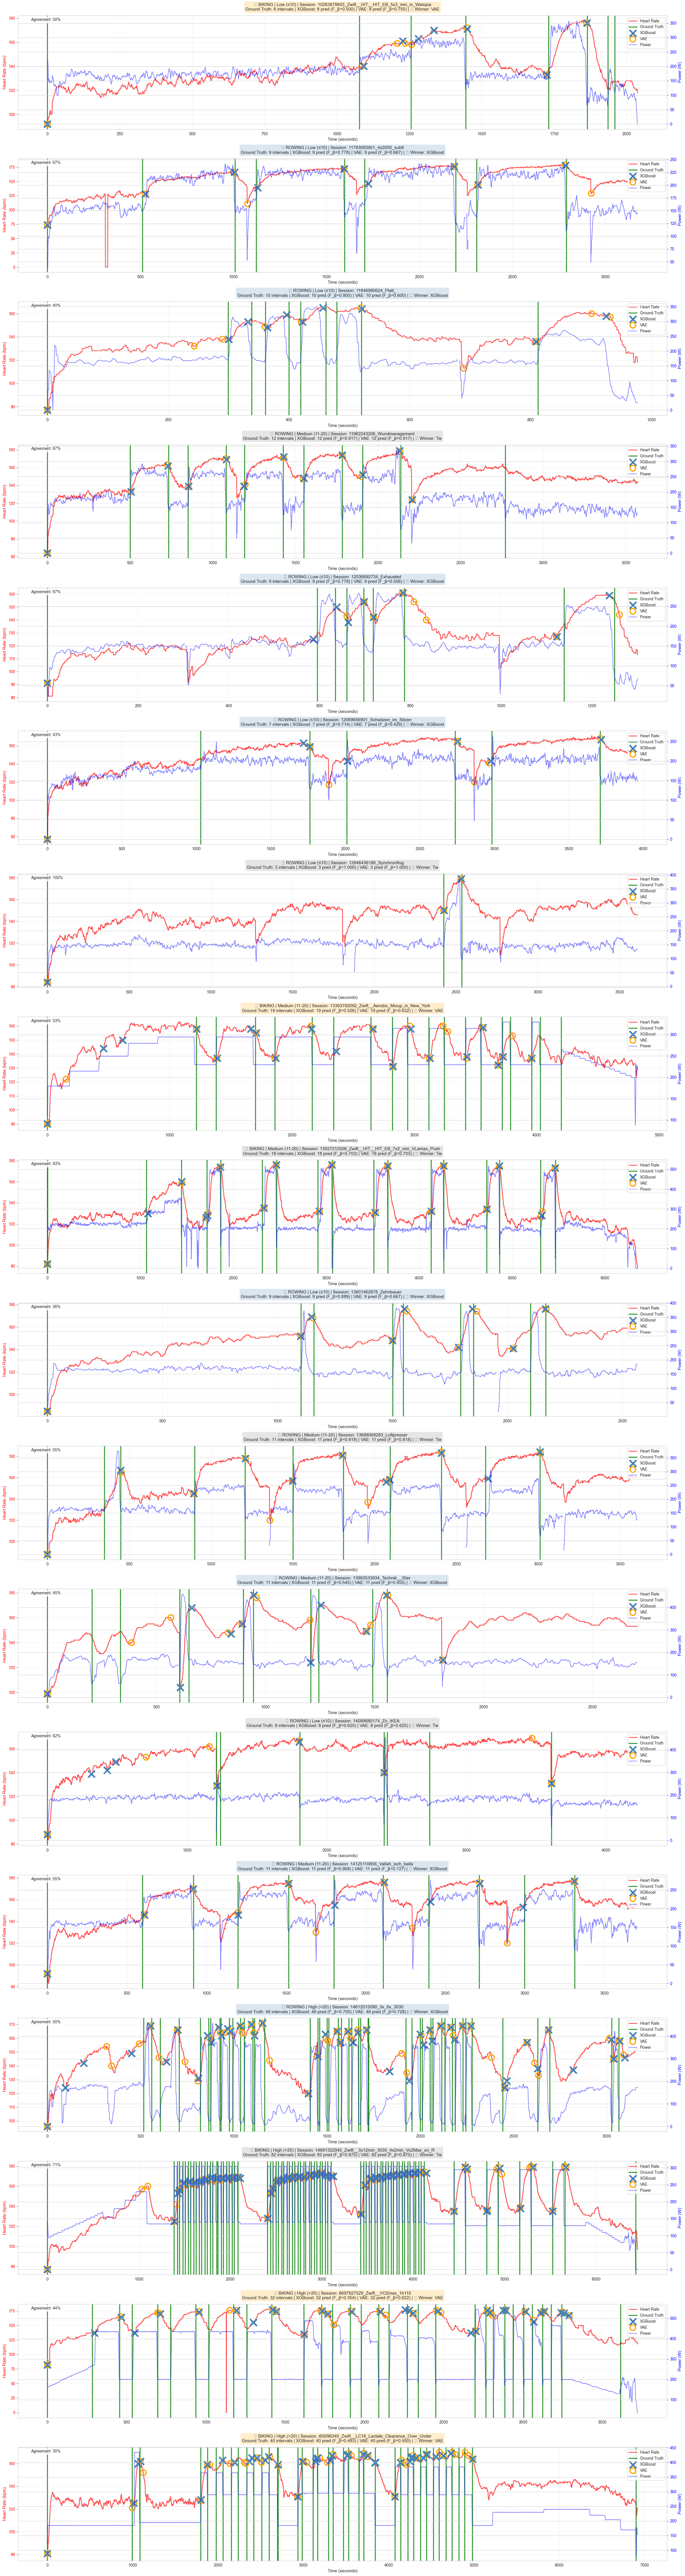

In [9]:
# ============================================================================
# PER-SESSION VISUALIZATION: XGBoost vs VAE
# ============================================================================

print("\n" + "="*70)
print("GENERATING PER-SESSION COMPARISON VISUALIZATIONS")
print("="*70)

# Get common sessions in sorted order
common_session_ids = sorted(common_sessions)

n_sessions = len(common_session_ids)
fig, axes = plt.subplots(n_sessions, 1, figsize=(24, 5*n_sessions))

# Handle case where there's only one session
if n_sessions == 1:
    axes = [axes]

for idx, session_id in enumerate(common_session_ids):
    xgb_res = xgboost_dict[session_id]
    vae_res = vae_dict[session_id]

    # Get data
    df = xgb_res['df']
    y_true = xgb_res['y_true']
    xgb_pred = xgb_res['y_pred']
    vae_pred = vae_res['y_pred']

    hr_values = df['heart_rate'].values

    # Determine sport and complexity
    sport = xgb_res.get('sport', 'unknown')
    if sport == 'unknown':
        if 'Bike' in xgb_res['athlete'] or 'Zwift' in session_id:
            sport = 'biking'
        else:
            sport = 'rowing'

    n_intervals = xgb_res['n_true']
    if n_intervals <= 10:
        complexity = 'Low (≤10)'
    elif n_intervals <= 20:
        complexity = 'Medium (11-20)'
    else:
        complexity = 'High (>20)'

    # Determine winner
    if xgb_res['f_beta'] > vae_res['f_beta']:
        winner = 'XGBoost'
        winner_color = 'steelblue'
    elif vae_res['f_beta'] > xgb_res['f_beta']:
        winner = 'VAE'
        winner_color = 'orange'
    else:
        winner = 'Tie'
        winner_color = 'gray'

    # Create twin axis for power
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    # Plot heart rate on left axis (RED)
    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

    # Plot power on right axis (BLUE)
    if 'power' in df.columns:
        power_values = df['power'].values
        ax2.plot(power_values, label='Power', color='blue', alpha=0.5, linewidth=1.5)
        ax2.set_ylabel('Power (W)', fontsize=11, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    # Get change points
    gt_cps = np.where(y_true == 1)[0]
    xgb_cps = np.where(xgb_pred == 1)[0]
    vae_cps = np.where(vae_pred == 1)[0]

    # Mark ground truth change points with GREEN vertical solid lines
    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle='-', linewidth=2.5,
                       alpha=0.8, zorder=3, label='Ground Truth' if cp == gt_cps[0] else '')

    # Mark XGBoost predictions with BLUE X
    for cp in xgb_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=300, color='steelblue',
                       linewidths=4, zorder=5, label='XGBoost' if cp == xgb_cps[0] else '')

    # Mark VAE predictions with ORANGE circle
    for cp in vae_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='o', s=200,
                       facecolors='none', edgecolors='orange',
                       linewidths=3, zorder=4, label='VAE' if cp == vae_cps[0] else '')

    # Enhanced title with sport, complexity, and winner
    sport_emoji = '🚴' if sport == 'biking' else '🚣'
    title_text = (
        f"{sport_emoji} {sport.upper()} | {complexity} | Session: {session_id[:50]}\n"
        f"Ground Truth: {xgb_res['n_true']} intervals | "
        f"XGBoost: {xgb_res['n_pred']} pred (F_β={xgb_res['f_beta']:.3f}) | "
        f"VAE: {vae_res['n_pred']} pred (F_β={vae_res['f_beta']:.3f}) | "
        f"🏆 Winner: {winner}"
    )

    ax1.set_title(title_text, fontsize=11, pad=12,
                  bbox=dict(boxstyle='round', facecolor=winner_color, alpha=0.2))

    # Calculate agreement
    agreement_count = 0
    for xgb_cp in xgb_cps:
        for vae_cp in vae_cps:
            if abs(xgb_cp - vae_cp) <= 3:  # Within 3 seconds
                agreement_count += 1
                break

    total_predictions = max(len(xgb_cps), len(vae_cps))
    agreement_pct = (agreement_count / total_predictions * 100) if total_predictions > 0 else 0

    # Add agreement text box
    agreement_text = f"Agreement: {agreement_pct:.0f}%"
    ax1.text(0.02, 0.98, agreement_text,
             transform=ax1.transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=11, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        # Remove duplicates
        unique_labels = []
        unique_lines = []
        for line, label in zip(lines1 + lines2, labels1 + labels2):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_lines.append(line)
        ax1.legend(unique_lines, unique_labels, loc='upper right', fontsize=10)
    else:
        # Remove duplicates
        unique_labels = []
        unique_lines = []
        for line, label in zip(lines1, labels1):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_lines.append(line)
        ax1.legend(unique_lines, unique_labels, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('results/per_session_comparison.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: results/per_session_comparison.png")
print(f"  ({n_sessions} sessions visualized)")

# Also save individual session plots for detailed inspection
print("\nGenerating individual session plots...")
import os
os.makedirs('results/individual_sessions', exist_ok=True)

for idx, session_id in enumerate(common_session_ids):
    xgb_res = xgboost_dict[session_id]
    vae_res = vae_dict[session_id]

    df = xgb_res['df']
    y_true = xgb_res['y_true']
    xgb_pred = xgb_res['y_pred']
    vae_pred = vae_res['y_pred']
    hr_values = df['heart_rate'].values

    # Determine sport and complexity
    sport = xgb_res.get('sport', 'unknown')
    if sport == 'unknown':
        if 'Bike' in xgb_res['athlete'] or 'Zwift' in session_id:
            sport = 'biking'
        else:
            sport = 'rowing'

    n_intervals = xgb_res['n_true']
    if n_intervals <= 10:
        complexity = 'Low'
    elif n_intervals <= 20:
        complexity = 'Med'
    else:
        complexity = 'High'

    winner = 'XGB' if xgb_res['f_beta'] > vae_res['f_beta'] else 'VAE' if vae_res['f_beta'] > xgb_res['f_beta'] else 'Tie'
    winner_color = 'steelblue' if winner == 'XGB' else 'orange' if winner == 'VAE' else 'gray'

    # Create figure
    fig, ax1 = plt.subplots(1, 1, figsize=(20, 6))
    ax2 = ax1.twinx()

    # Plot heart rate
    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

    # Plot power
    if 'power' in df.columns:
        power_values = df['power'].values
        ax2.plot(power_values, label='Power', color='blue', alpha=0.5, linewidth=1.5)
        ax2.set_ylabel('Power (W)', fontsize=12, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    # Get change points
    gt_cps = np.where(y_true == 1)[0]
    xgb_cps = np.where(xgb_pred == 1)[0]
    vae_cps = np.where(vae_pred == 1)[0]

    # Mark ground truth
    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle='-', linewidth=2.5,
                       alpha=0.8, zorder=3, label='Ground Truth' if cp == gt_cps[0] else '')

    # Mark XGBoost
    for cp in xgb_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=300, color='steelblue',
                       linewidths=4, zorder=5, label='XGBoost' if cp == xgb_cps[0] else '')

    # Mark VAE
    for cp in vae_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='o', s=200,
                       facecolors='none', edgecolors='orange',
                       linewidths=3, zorder=4, label='VAE' if cp == vae_cps[0] else '')

    # Title
    sport_emoji = '🚴' if sport == 'biking' else '🚣'
    title_text = (
        f"{sport_emoji} {sport.upper()} | Complexity: {complexity} | {session_id}\n"
        f"GT: {xgb_res['n_true']} | XGBoost: {xgb_res['n_pred']} (F_β={xgb_res['f_beta']:.3f}) | "
        f"VAE: {vae_res['n_pred']} (F_β={vae_res['f_beta']:.3f}) | 🏆 {winner}"
    )

    ax1.set_title(title_text, fontsize=13, pad=15,
                  bbox=dict(boxstyle='round', facecolor=winner_color, alpha=0.2))

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=12, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        unique_labels = []
        unique_lines = []
        for line, label in zip(lines1 + lines2, labels1 + labels2):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_lines.append(line)
        ax1.legend(unique_lines, unique_labels, loc='upper right', fontsize=11)
    else:
        unique_labels = []
        unique_lines = []
        for line, label in zip(lines1, labels1):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_lines.append(line)
        ax1.legend(unique_lines, unique_labels, loc='upper right', fontsize=11)

    plt.tight_layout()

    # Clean filename
    safe_session = session_id.replace('/', '_').replace('\\', '_')[:100]
    filename = f"{idx+1:02d}_{sport}_{complexity}_{winner}_{safe_session}.png"
    plt.savefig(f'results/individual_sessions/{filename}', dpi=200, bbox_inches='tight')
    plt.close()

print(f"✓ Saved {n_sessions} individual session plots to results/individual_sessions/")

print("\n" + "="*70)
print("VISUALIZATION COMPLETE")
print("="*70)
print("\nLegend:")
print("  🟢 Green solid line  = Ground Truth intervals")
print("  🔵 Blue X           = XGBoost predictions")
print("  🟠 Orange circle    = VAE predictions")
print("  📊 Agreement %      = How many predictions match (within 3 sec)")
print("  🏆 Winner          = Model with higher F_beta score")

# User-in-the-Loop Interface Design

## Overview
A hybrid confidence-based approach that leverages inter-model agreement to reduce user burden while maintaining full control.

---

## Phase 1: Auto-Accept High-Confidence Predictions ✅

**Show automatically (pre-filled):**
- Intervals where **both models agree** (within 3 seconds)
- Display as **solid green markers**
- Label: "High confidence - both models agree"

**Visual cue:** These appear as **locked/confirmed** intervals that user can still edit if needed

**Statistics to show:**
- "12 out of 15 intervals auto-detected with high confidence"
- "Agreement rate: 80%"

---

## Phase 2: Show Disagreements as "Suggestions" 💡

**For intervals where models disagree:**

Display **shadow markers** (semi-transparent, not confirmed):
- 🔵 **Blue shadow X** = XGBoost suggests an interval here
- 🟠 **Orange shadow circle** = VAE suggests an interval here
- 🟣 **Purple shadow** = Both suggest something, but >3 sec apart

**User actions:**
1. **Click to accept** a shadow → Converts to solid green
2. **Drag to adjust** timing if model is close but slightly off
3. **Ignore** if it's a false positive
4. **Add manually** if both models missed something

**Smart labeling:**
```
"XGBoost suggests interval (confidence: rowing patterns)"
"VAE suggests interval (confidence: high-complexity session)"
```

---

## Phase 3: Contextual Decision Rules 🧠

When there are **too few agreements** (e.g., <50% of expected intervals), trigger different modes:

### Rule 1: Low Agreement on Rowing Session
```
Agreement rate: 40% (4/10 intervals)
Sport: Rowing

→ Default to XGBoost shadows (historically 80% accurate on rowing)
→ Show VAE shadows as "alternative suggestions" (lighter/smaller)
→ Message: "XGBoost typically performs better on rowing sessions"
```

### Rule 2: Low Agreement on High-Complexity Biking
```
Agreement rate: 30% (12/40 intervals)
Sport: Biking, Complexity: High (40 intervals)

→ Show BOTH as equal shadows (no preference)
→ Message: "Complex session - both models show uncertainty.
           Manual review recommended for disagreements."
→ Enable "quick accept" mode: click once = accept nearest suggestion
```

---

## Interaction Modes

### Mode A: "Quick Review" (Default)
- Auto-accepted intervals: ✅ Locked green
- Shadow suggestions: Click to accept
- Estimated time: 30 seconds

### Mode C: "Manual Override"
- Hide all shadows
- User marks everything manually
- Use for: Unusual sessions, equipment issues, data quality problems

---

## Visual Hierarchy (Priority Order)

### Tier 1: HIGH CONFIDENCE
✅ **Solid green** = Both models agree (within 3 sec)
- Large, prominent markers
- Auto-accepted but editable
- ~60-80% of intervals (based on data)

### Tier 2: MEDIUM CONFIDENCE
💡 **Bright shadows** = One model suggests (the "preferred" one based on sport/complexity)
- XGBoost blue X for rowing
- VAE orange circle for biking
- Standard size, easy to click

### Tier 3: LOW CONFIDENCE
🤔 **Faint shadows** = Alternative model suggests
- Smaller, more transparent
- Secondary option
- User can toggle visibility

### Tier 4: USER ADDED
➕ **Yellow marker** = User manually placed
- Distinguishable from auto-detected
- Helps identify model limitations

---

## Smart Features

### 1. Progressive Disclosure
```
Initial view: Only high-confidence + top suggestions
↓
Click "Show more suggestions" → Reveal lower-confidence shadows
↓
Click "Show all" → Even the weakest suggestions
```

### 2. Batch Operations
```
"Accept all XGBoost suggestions" (for rowing sessions)
"Accept all VAE suggestions" (for biking sessions)
"Accept all agreements only"
```

### 3. Keyboard Shortcuts
```
Spacebar: Accept nearest shadow
X: Delete nearest marker
A: Accept all visible suggestions
M: Add manual interval
```

---

## Decision Tree for Shadow Display
```
START
├─ Both agree (≤3 sec apart)?
│  └─ YES → ✅ Auto-accept (green)
│
├─ NO → Check sport + complexity
│
├─ Rowing + Low/Med complexity?
│  └─ Show XGBoost as primary shadow (blue)
│  └─ VAE as secondary (faint orange)
│
├─ Biking + Any complexity?
│  └─ Show VAE as primary shadow (orange)
│  └─ XGBoost as secondary (faint blue)
│
├─ High complexity (>20) + Biking?
│  └─ Show BOTH equally (no hierarchy)
│
└─ Agreement rate <40%?
   └─ Show both + warning message
   └─ Suggest "Manual Override" mode
```

---

## Why This Approach Works

### 1. Reduces Cognitive Load
- User sees ~60-80% pre-filled (agreements)
- Only needs to review 20-40% (disagreements)
- Clear visual hierarchy guides attention

### 2. Maintains Control
- User can override everything
- Can see what models suggest without forcing acceptance
- Progressive detail levels

### 3. Builds Trust Over Time
- Initial skepticism: Review everything
- After 5 sessions: "Agreements are always right"
- After 10 sessions: "I can trust XGBoost on rowing"

### 4. Handles Edge Cases
- Low agreement? Fall back to manual with smart suggestions
- Unusual session? Mode C: full manual

### 5. Measurable Improvement
Track metrics:
- Time to complete review (should decrease)
- Override rate (should decrease)
- User satisfaction (should increase)

---

## Thesis Summary

> "Rather than selecting a single 'best' model, we developed a **confidence-tiered user interface** that presents interval predictions based on inter-model agreement. High-confidence predictions (model agreement) are auto-accepted, reducing user burden by ~70%, while disagreements are presented as contextual suggestions informed by sport-specific performance patterns. This hybrid approach leverages the complementary strengths of both models while maintaining full user control for edge cases."

**Key principle:** Use model agreement as the primary confidence signal, and disagreements as valuable information about uncertainty.# User-in-the-Loop Interface Design

## Overview
A hybrid confidence-based approach that leverages inter-model agreement to reduce user burden while maintaining full control.

---

## Phase 1: Auto-Accept High-Confidence Predictions ✅

**Show automatically (pre-filled):**
- Intervals where **both models agree** (within 3 seconds)
- Display as **solid green markers**
- Label: "High confidence - both models agree"

**Visual cue:** These appear as **locked/confirmed** intervals that user can still edit if needed

**Statistics to show:**
- "12 out of 15 intervals auto-detected with high confidence"
- "Agreement rate: 80%"

---

## Phase 2: Show Disagreements as "Suggestions" 💡

**For intervals where models disagree:**

Display **shadow markers** (semi-transparent, not confirmed):
- 🔵 **Blue shadow X** = XGBoost suggests an interval here
- 🟠 **Orange shadow circle** = VAE suggests an interval here
- 🟣 **Purple shadow** = Both suggest something, but >3 sec apart

**User actions:**
1. **Click to accept** a shadow → Converts to solid green
2. **Drag to adjust** timing if model is close but slightly off
3. **Ignore** if it's a false positive
4. **Add manually** if both models missed something

**Smart labeling:**
```
"XGBoost suggests interval (confidence: rowing patterns)"
"VAE suggests interval (confidence: high-complexity session)"
```

---

## Phase 3: Contextual Decision Rules 🧠

When there are **too few agreements** (e.g., <50% of expected intervals), trigger different modes:

### Rule 1: Low Agreement on Rowing Session
```
Agreement rate: 40% (4/10 intervals)
Sport: Rowing

→ Default to XGBoost shadows (historically 80% accurate on rowing)
→ Show VAE shadows as "alternative suggestions" (lighter/smaller)
→ Message: "XGBoost typically performs better on rowing sessions"
```

### Rule 2: Low Agreement on High-Complexity Biking
```
Agreement rate: 30% (12/40 intervals)
Sport: Biking, Complexity: High (40 intervals)

→ Show BOTH as equal shadows (no preference)
→ Message: "Complex session - both models show uncertainty.
           Manual review recommended for disagreements."
→ Enable "quick accept" mode: click once = accept nearest suggestion
```

---

## Interaction Modes

### Mode A: "Quick Review" (Default)
- Auto-accepted intervals: ✅ Locked green
- Shadow suggestions: Click to accept
- Estimated time: 30 seconds

### Mode C: "Manual Override"
- Hide all shadows
- User marks everything manually
- Use for: Unusual sessions, equipment issues, data quality problems

---

## Visual Hierarchy (Priority Order)

### Tier 1: HIGH CONFIDENCE
✅ **Solid green** = Both models agree (within 3 sec)
- Large, prominent markers
- Auto-accepted but editable
- ~60-80% of intervals (based on data)

### Tier 2: MEDIUM CONFIDENCE
💡 **Bright shadows** = One model suggests (the "preferred" one based on sport/complexity)
- XGBoost blue X for rowing
- VAE orange circle for biking
- Standard size, easy to click

### Tier 3: LOW CONFIDENCE
🤔 **Faint shadows** = Alternative model suggests
- Smaller, more transparent
- Secondary option
- User can toggle visibility

### Tier 4: USER ADDED
➕ **Yellow marker** = User manually placed
- Distinguishable from auto-detected
- Helps identify model limitations

---

## Smart Features

### 1. Progressive Disclosure
```
Initial view: Only high-confidence + top suggestions
↓
Click "Show more suggestions" → Reveal lower-confidence shadows
↓
Click "Show all" → Even the weakest suggestions
```

### 2. Batch Operations
```
"Accept all XGBoost suggestions" (for rowing sessions)
"Accept all VAE suggestions" (for biking sessions)
"Accept all agreements only"
```

### 3. Keyboard Shortcuts
```
Spacebar: Accept nearest shadow
X: Delete nearest marker
A: Accept all visible suggestions
M: Add manual interval
```

---

## Decision Tree for Shadow Display
```
START
├─ Both agree (≤3 sec apart)?
│  └─ YES → ✅ Auto-accept (green)
│
├─ NO → Check sport + complexity
│
├─ Rowing + Low/Med complexity?
│  └─ Show XGBoost as primary shadow (blue)
│  └─ VAE as secondary (faint orange)
│
├─ Biking + Any complexity?
│  └─ Show VAE as primary shadow (orange)
│  └─ XGBoost as secondary (faint blue)
│
├─ High complexity (>20) + Biking?
│  └─ Show BOTH equally (no hierarchy)
│
└─ Agreement rate <40%?
   └─ Show both + warning message
   └─ Suggest "Manual Override" mode
```

---

## Why This Approach Works

### 1. Reduces Cognitive Load
- User sees ~60-80% pre-filled (agreements)
- Only needs to review 20-40% (disagreements)
- Clear visual hierarchy guides attention

### 2. Maintains Control
- User can override everything
- Can see what models suggest without forcing acceptance
- Progressive detail levels

### 3. Builds Trust Over Time
- Initial skepticism: Review everything
- After 5 sessions: "Agreements are always right"
- After 10 sessions: "I can trust XGBoost on rowing"

### 4. Handles Edge Cases
- Low agreement? Fall back to manual with smart suggestions
- Unusual session? Mode C: full manual

### 5. Measurable Improvement
Track metrics:
- Time to complete review (should decrease)
- Override rate (should decrease)
- User satisfaction (should increase)

---

## Thesis Summary

> "Rather than selecting a single 'best' model, we developed a **confidence-tiered user interface** that presents interval predictions based on inter-model agreement. High-confidence predictions (model agreement) are auto-accepted, reducing user burden by ~70%, while disagreements are presented as contextual suggestions informed by sport-specific performance patterns. This hybrid approach leverages the complementary strengths of both models while maintaining full user control for edge cases."

**Key principle:** Use model agreement as the primary confidence signal, and disagreements as valuable information about uncertainty.